<a href="https://colab.research.google.com/github/Krouw/DataScience_240401010367_DimoriansaRamadhan/blob/main/Pertemuan12_Dimoriansa_Ramadhan_240401010367.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama  : Dimoriansa Ramadhan

NIM   : 240401010367

Kelas : IF-403

Contoh 3 transaksi pertama:
Transaksi 1: [np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai']
Transaksi 2: [np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')]
Transaksi 3: [np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')]

Jumlah transaksi: 50

Frekuensi Tiap Produk
    Produk  Frekuensi
4    Selai         26
5      Teh         23
2  Mentega         21
7    Telur         18
0     Keju         17
1     Roti         16
3     Kopi         16
6     Susu         16
8     Gula         16
9   Sereal          9


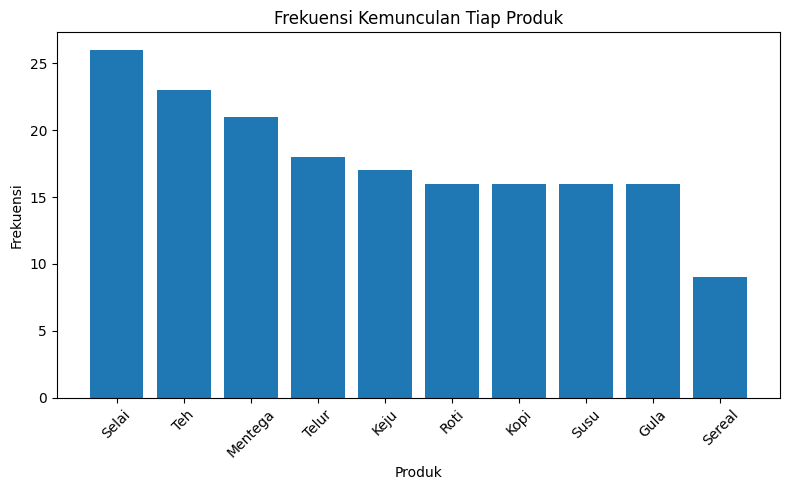

In [ ]:
# Langkah 1 : Generate & Eksplorasi Dataset Transaksi
# Buat dataset transaksi sintetis dengan pola pembelian tersembunyi, lalu eksplorasi frekuensi tiap produk.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
produk = ['Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
          'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega']

# Buat 50 transaksi, tiap transaksi berisi 2-5 produk
transaksi = []
for i in range(50):
    jumlah_item = np.random.randint(2, 6)
    item = list(np.random.choice(produk, jumlah_item, replace=False))
    transaksi.append(item)

# Roti sering bersama Selai
for i in range(20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

print("Contoh 3 transaksi pertama:")
for i in range(3):
    print(f"Transaksi {i+1}: {transaksi[i]}")

print(f"\nJumlah transaksi: {len(transaksi)}")


# Eksplorasi Frekuensi Tiap Produk

# Menghitung frekuensi kemunculan setiap produk
frekuensi = {}

for transaksi_item in transaksi:
    for item in transaksi_item:
        frekuensi[item] = frekuensi.get(item, 0) + 1

# Mengubah ke DataFrame agar lebih rapi
df_frekuensi = (
    pd.DataFrame(
        frekuensi.items(),
        columns=["Produk", "Frekuensi"]
    )
    .sort_values(by="Frekuensi", ascending=False)
)

# Menampilkan tabel frekuensi
print("\nFrekuensi Tiap Produk")
print(df_frekuensi)

# Visualisasi Frekuensi Produk

plt.figure(figsize=(8, 5))
plt.bar(df_frekuensi["Produk"], df_frekuensi["Frekuensi"])
plt.title("Frekuensi Kemunculan Tiap Produk")
plt.xlabel("Produk")
plt.ylabel("Frekuensi")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Langkah 2 : One-Hot Encoding Transaksi
# Ubah daftar transaksi menjadi tabel one-hot encoding menggunakan TransactionEncoder.

from mlxtend.preprocessing import TransactionEncoder

# Membuat objek TransactionEncoder
te = TransactionEncoder()

# Melatih encoder menggunakan data transaksi
te_ary = te.fit(transaksi).transform(transaksi)

# Mengubah array boolean menjadi DataFrame pandas
df = pd.DataFrame(te_ary, columns=te.columns_)

# Menampilkan 5 baris pertama dari hasil one-hot encoding
print(df.head())

    Gula   Keju   Kopi  Mentega   Roti  Selai  Sereal   Susu    Teh  Telur
0  False   True   True     True   True   True   False  False  False  False
1  False  False   True     True   True   True   False  False   True  False
2  False  False   True    False  False  False   False   True   True  False
3  False   True  False    False  False   True   False  False   True   True
4   True   True  False     True  False  False   False   True  False  False


In [ ]:
# Mengimpor fungsi apriori dari library mlxtend
from mlxtend.frequent_patterns import apriori

# Mencoba beberapa nilai minimum support
for ms in [0.05, 0.1, 0.2]:

    # Mencari frequent itemset berdasarkan nilai min_support
    freq = apriori(df, min_support=ms, use_colnames=True)

    # Menampilkan jumlah itemset yang ditemukan
    print(f"min_support={ms}: {len(freq)} itemset ditemukan")

# Menggunakan nilai min_support = 0.1
freq_items = apriori(df, min_support=0.1, use_colnames=True)

# Mengurutkan itemset berdasarkan nilai support dari terbesar ke terkecil
freq_items = freq_items.sort_values("support", ascending=False)

# Menampilkan 10 frequent itemset dengan nilai support tertinggi
print(freq_items.head(10))

min_support=0.05: 74 itemset ditemukan
min_support=0.1: 44 itemset ditemukan
min_support=0.2: 13 itemset ditemukan
    support      itemsets
5      0.52       (Selai)
8      0.46         (Teh)
3      0.42     (Mentega)
9      0.36       (Telur)
1      0.34        (Keju)
0      0.32        (Gula)
2      0.32        (Kopi)
4      0.32        (Roti)
7      0.32        (Susu)
36     0.24  (Selai, Teh)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Langkah 4 : Bentuk & Saring Aturan Asosiasi
# Bentuk aturan asosiasi, saring dengan min_confidence dan min_lift, lalu urutkan berdasarkan Lift tertinggi.

# Mengimpor fungsi association_rules dari library mlxtend
from mlxtend.frequent_patterns import association_rules

# Membentuk aturan asosiasi dengan minimum confidence 0.5
rules = association_rules(
    freq_items,
    metric="confidence",
    min_threshold=0.5
)

# Menyaring aturan yang memiliki nilai lift lebih dari 1
rules = rules[rules["lift"] > 1]

# Mengurutkan aturan berdasarkan nilai lift dari terbesar ke terkecil
rules = rules.sort_values("lift", ascending=False)

# Menampilkan 10 aturan asosiasi teratas
print(
    rules[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ].head(10)
)

# Interpretasikan dalam sel Markdown:
# Aturan mana yang paling kuat (Lift tertinggi)?
# Apakah masuk akal secara bisnis (mis. Roti -> Selai)?

         antecedents consequents  support  confidence      lift
10       (Keju, Teh)     (Telur)     0.12    0.857143  2.380952
13  (Selai, Mentega)      (Kopi)     0.10    0.625000  1.953125
12      (Gula, Roti)     (Selai)     0.10    1.000000  1.923077
7           (Sereal)   (Mentega)     0.14    0.777778  1.851852
9       (Telur, Teh)      (Keju)     0.12    0.600000  1.764706
14     (Selai, Kopi)   (Mentega)     0.10    0.714286  1.700680
8      (Telur, Keju)       (Teh)     0.12    0.750000  1.630435
11     (Selai, Gula)      (Roti)     0.10    0.500000  1.562500
15   (Mentega, Kopi)     (Selai)     0.10    0.714286  1.373626
1             (Roti)     (Selai)     0.22    0.687500  1.322115


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Hasil interpretasi :

1. Aturan mana yang paling kuat (Lift tertinggi) ?

Aturan yang memiliki nilai lift tertinggi pada hasil Apriori. Nilai tersebut menunjukkan bahwa hubungan antarproduk lebih kuat dibandingkan jika pembelian terjadi secara acak.

2. Apakah masuk akal secara bisnis (mis. Roti → Selai) ?

Yes, karena kedua produk sering digunakan atau dikonsumsi bersama. Pola ini dapat dimanfaatkan untuk strategi seperti bundling produk atau menempatkan keduanya berdekatan agar peluang pembelian meningkat.

In [ ]:
# Langkah 5 : Rekomender Sederhana dengan Content-Based Filtering
# Bangun katalog produk dengan kategori, lalu buat rekomendasi produk serupa menggunakan cosine similarity atas kategori (one-hot).

# Mengimpor fungsi cosine_similarity
from sklearn.metrics.pairwise import cosine_similarity

# Membuat katalog produk beserta kategorinya
katalog = pd.DataFrame({
    "produk": produk,
    "kategori": [
        "Bakery", "Bakery", "Dairy", "Bakery", "Dairy",
        "Dairy", "Minuman", "Bumbu", "Minuman", "Dairy"
    ]
})

# Mengubah kategori menjadi bentuk one-hot encoding
fitur = pd.get_dummies(katalog["kategori"])

# Menghitung tingkat kemiripan antar produk
sim_matrix = cosine_similarity(fitur)

# Fungsi untuk mencari produk yang memiliki kategori serupa
def rekomendasi_serupa(nama_produk, top_n=3):
    # Mencari indeks produk yang dipilih
    idx = katalog.index[katalog["produk"] == nama_produk][0]

    # Mengambil nilai kemiripan produk dengan produk lainnya
    skor = list(enumerate(sim_matrix[idx]))

    # Mengurutkan berdasarkan nilai kemiripan tertinggi
    skor = sorted(skor, key=lambda x: x[1], reverse=True)

    # Menghapus produk itu sendiri dan mengambil sejumlah top_n rekomendasi
    skor = [s for s in skor if s[0] != idx][:top_n]

    # Mengembalikan nama produk yang direkomendasikan
    return katalog.iloc[[i for i, _ in skor]]["produk"].tolist()

# Menampilkan rekomendasi produk yang mirip dengan Roti
print("Mirip dengan Roti:", rekomendasi_serupa("Roti"))

Mirip dengan Roti: ['Selai', 'Sereal', 'Susu']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Langkah 6 : Bandingkan Kedua Pendekatan
# Bandingkan rekomendasi dari aturan asosiasi (Langkah 4) dengan rekomendasi ContentBased (Langkah 5) untuk produk yang sama.

# Menentukan produk yang akan dicari rekomendasinya
produk_target = "Roti"

# Mencari aturan asosiasi yang antecedent-nya
# mengandung produk target
rules_terkait = rules[
    rules["antecedents"].apply(
        lambda x: produk_target in x
    )
]

# Menampilkan rekomendasi berdasarkan Association Rules
print("Rekomendasi dari Association Rules:")
print(rules_terkait[["consequents", "lift"]].head())

# Menampilkan rekomendasi berdasarkan Content-Based Filtering
print("Rekomendasi dari Content-Based:", rekomendasi_serupa(produk_target))

# Diskusikan: apakah kedua pendekatan memberi rekomendasi yang konsisten?
# Kapan sebaiknya menggunakan salah satu, atau menggabungkan keduanya (hybrid)?

Rekomendasi dari Association Rules:
   consequents      lift
12     (Selai)  1.923077
1      (Selai)  1.322115
Rekomendasi dari Content-Based: ['Selai', 'Sereal', 'Susu']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

1. Apakah kedua pendekatan memberi rekomendasi yang konsisten ?

- Cukup konsisten, tetapi tidak selalu sama. Association Rules memberikan rekomendasi berdasarkan produk yang sering dibeli bersamaan, sedangkan Content-Based memberikan rekomendasi berdasarkan kesamaan kategori produk.

- Association Rules dapat merekomendasikan Selai karena sering dibeli bersama, sedangkan Content-Based bisa merekomendasikan Sereal karena sama-sama berada pada kategori Bakery. Jadi, hasilnya bisa berbeda meskipun sama-sama relevan.

2. Kapan sebaiknya menggunakan salah satu, atau menggabungkan keduanya (hybrid) ?

- Association Rules lebih cocok digunakan jika sudah tersedia banyak data transaksi, karena rekomendasinya berasal dari kebiasaan pembelian pelanggan.

- Content-Based lebih cocok ketika data transaksi masih sedikit atau ingin merekomendasikan produk yang memiliki karakteristik serupa. Jika memungkinkan, menggabungkan keduanya (hybrid) akan lebih baik karena dapat memanfaatkan pola pembelian sekaligus kesamaan produk, sehingga rekomendasi menjadi lebih akurat dan beragam.

Kesimpulan singkat :

Pada pertemuan ke 11 ini, saya memahami bahwa data transaksi dapat dimanfaatkan untuk mencari pola pembelian dan membuat rekomendasi produk. Metode Association Rules menunjukkan produk yang sering dibeli secara bersamaan, sedangkan Content-Based Filtering memberikan rekomendasi berdasarkan kemiripan kategori produk.

Temuan utama : adanya hubungan antara Roti dan Selai, sehingga keduanya sering muncul sebagai rekomendasi. Sementara itu, rekomendasi dari Content-Based lebih banyak didasarkan pada produk yang berada dalam kategori yang sama.

Keterbatasan praktikum ini adalah data yang digunakan masih berupa data contoh dengan jumlah transaksi yang terbatas. Karena itu, hasil yang diperoleh belum tentu mencerminkan pola belanja yang sebenarnya jika diterapkan pada data penjualan di dunia nyata.